# 🎯 Buy the Dip Detector — Modelling (Classifier)

Notebook ini melatih **1 model klasifikasi biner** untuk mendeteksi momen "Buy the Dip".

**Label:**
- `1` = Hari ini adalah momen beli (harga naik ≥3% dalam 5 hari, drawdown tidak lebih dari -5%)
- `0` = Bukan momen beli

**Output:** File model `.pkl` yang siap digunakan oleh `backtest_classifier.ipynb`.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from src.data_loader import load_stock_data
from src.features import create_features
from src.label import create_labels
from src.model_config import FEATURES, CLASSIFIER_CONFIGS
from src.modelling import ClassificationPipeline, ClassificationEvaluator
from sklearn.dummy import DummyClassifier

# ==================== KONFIGURASI ====================
TICKER = 'BUMI.JK'
IN_SAMPLE_END = '2023-12-31'    # Data latih: 2015 - 2023
OOS_START = '2024-01-01'        # Data uji: 2024 - 2025
OOS_END = '2025-12-31'
TODAY = datetime.now().strftime('%Y-%m-%d')
TARGET_NAME = 'is_buy_dip'

# Model yang ingin diadu
MODELS_NAME = ['xgb_classifier', 'lgbm_classifier', 'rf_classifier', 'svc']

print(f"Ticker: {TICKER}")
print(f"Features: {len(FEATURES)} fitur")
print(f"Models: {MODELS_NAME}")

Ticker: BUMI.JK
Features: 21 fitur
Models: ['xgb_classifier', 'lgbm_classifier', 'rf_classifier', 'svc']


In [2]:
# ==================== LOAD & PREPARE DATA ====================
df_raw = load_stock_data(ticker=TICKER, start_date='2014-11-01', end_date=TODAY)
df = create_features(df_raw.copy())
df = create_labels(df)

# Cek distribusi label
label_dist = df[TARGET_NAME].value_counts()
print(f"\n=== Distribusi Label '{TARGET_NAME}' ===")
print(f"  0 (Bukan Dip) : {label_dist.get(0, 0)} hari ({label_dist.get(0, 0)/len(df)*100:.1f}%)")
print(f"  1 (Buy Dip)   : {label_dist.get(1, 0)} hari ({label_dist.get(1, 0)/len(df)*100:.1f}%)")
print(f"  NaN           : {df[TARGET_NAME].isna().sum()} hari")

# Split In-Sample dan Out-of-Sample
df_in_sample = df.loc[:IN_SAMPLE_END].copy()
df_oos = df.loc[OOS_START:OOS_END].copy()

print(f"\nIn-Sample  : {len(df_in_sample)} baris ({df_in_sample.index[0].date()} s.d {df_in_sample.index[-1].date()})")
print(f"Out-of-Sample: {len(df_oos)} baris ({df_oos.index[0].date()} s.d {df_oos.index[-1].date()})")

# Cek distribusi label
label_dist_in = df_in_sample[TARGET_NAME].value_counts()
print(f"\n=== Distribusi Label '{TARGET_NAME}' | In-Sample ===")
print(f"  0 (Bukan Dip) : {label_dist_in.get(0, 0)} hari ({label_dist_in.get(0, 0)/len(df_in_sample)*100:.1f}%)")
print(f"  1 (Buy Dip)   : {label_dist_in.get(1, 0)} hari ({label_dist_in.get(1, 0)/len(df_in_sample)*100:.1f}%)")
print(f"  NaN           : {df_in_sample[TARGET_NAME].isna().sum()} hari")

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 2901 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 123 baris data (NaN atau Volume 0).
Berhasil memuat 2778 baris data bersih untuk BUMI.JK.


c:\Users\YOGA\OneDrive\Documents\Repositories\stock-forecasting\notebook\..\src\features.py:218: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ATR_Pct_Change'] = (atr_raw.pct_change(periods=5)).shift(1)



=== Distribusi Label 'is_buy_dip' ===
  0 (Bukan Dip) : 2508 hari (90.2%)
  1 (Buy Dip)   : 271 hari (9.8%)
  NaN           : 0 hari

In-Sample  : 2159 baris (2014-11-03 s.d 2023-12-29)
Out-of-Sample: 473 baris (2024-01-02 s.d 2025-12-30)

=== Distribusi Label 'is_buy_dip' | In-Sample ===
  0 (Bukan Dip) : 1966 hari (91.1%)
  1 (Buy Dip)   : 193 hari (8.9%)
  NaN           : 0 hari


### deep analysis

In [3]:
# ==================== DEEP ANALYSIS ====================
from src.deep_analysis_classifier import (
    analyze_label_thresholds,
    analyze_feature_importance,
    robustness_test,
    threshold_sensitivity_analysis
)


In [8]:
from importlib import reload
import src.deep_analysis_classifier as dac
reload(dac)
from src.deep_analysis_classifier import find_sweet_spot_threshold

df_sweet = find_sweet_spot_threshold(df)
df_sweet[~df_sweet['disqualified']].sort_values('combined_score', ascending=False)



  SWEET SPOT FINDER — F1 Cukup + Statistik Signifikan
  (Mungkin memakan waktu 5-15 menit...)

  3%/-2%: Pos=19.3% | F1=0.219±0.060 | p=0.60 | CV=0.27 | Score=0.0000 | Sig❌ F1✅ Freq✅ Stbl✅ [DISQUALIFIED: p=0.60]
  3%/-3%: Pos=25.0% | F1=0.334±0.085 | p=0.00 | CV=0.26 | Score=0.0164 | Sig✅ F1✅ Freq❌ Stbl✅
  3%/-5%: Pos=36.0% | F1=0.447±0.117 | p=0.00 | CV=0.26 | Score=0.0001 | Sig✅ F1✅ Freq❌ Stbl✅ [DISQUALIFIED: Freq=36.0%]
  5%/-2%: Pos=17.0% | F1=0.169±0.086 | p=0.96 | CV=0.51 | Score=0.0000 | Sig❌ F1✅ Freq✅ Stbl⚠️ [DISQUALIFIED: p=0.96]
  5%/-3%: Pos=21.8% | F1=0.264±0.104 | p=0.34 | CV=0.39 | Score=0.0000 | Sig❌ F1✅ Freq❌ Stbl✅ [DISQUALIFIED: p=0.34]
  5%/-5%: Pos=28.9% | F1=0.339±0.148 | p=0.22 | CV=0.44 | Score=0.0000 | Sig❌ F1✅ Freq❌ Stbl✅ [DISQUALIFIED: Freq=28.9%, p=0.22]
  6%/-2%: Pos=15.6% | F1=0.162±0.063 | p=0.98 | CV=0.39 | Score=0.0000 | Sig❌ F1✅ Freq✅ Stbl✅ [DISQUALIFIED: p=0.98]
  6%/-3%: Pos=19.9% | F1=0.242±0.085 | p=0.52 | CV=0.35 | Score=0.0000 | Sig❌ F1✅ Freq✅ Stb

,min_return,max_drawdown,pct_positive,mean_f1,std_f1,p_value,cv_coef,sig_score,freq_score,stab_score,combined_score,n_positive,disqualified
26,0.15,-0.05,8.8,0.1546,0.0856,0.04,0.554,0.7333,0.9334,0.4463,0.0472,185,False
1,0.03,-0.03,25.0,0.3335,0.0854,0.00,0.256,1.0000,0.0660,0.7440,0.0164,527,False
19,0.12,-0.03,10.2,0.1589,0.0899,0.16,0.566,0.0000,0.9920,0.4339,0.0000,216,False



  ROBUSTNESS TEST

  [A] Cross-Period Stability (F1 per fold):
    Fold 1: F1=0.000
    Fold 2: F1=0.158
    Fold 3: F1=0.179
    Fold 4: F1=0.263
    Fold 5: F1=0.172

    Mean F1: 0.155 ± 0.086 | CV=0.55
    => TIDAK STABIL — Model tidak punya edge yang nyata, hanya noise

  [B] Permutation Test (50 iterasi — apakah model > random?):
    Real F1         : 0.155
    Random F1 (mean): 0.123 ± 0.018
    p-value         : 0.060 (Random yg mengalahkan Real: 6.0%)
    => LEMAH — Sedikit di atas keberuntungan

  [C] Feature Subset Test:

  FEATURE IMPORTANCE ANALYSIS

  [Mutual Information Scores]
                EMA50_Slope | 0.0388 | ███████
                        RSI | 0.0362 | ███████
                  MACD_Hist | 0.0317 | ██████
     distance_to_resistance | 0.0304 | ██████
                      RSI_3 | 0.0285 | █████
        distance_to_support | 0.0262 | █████
                 Williams_R | 0.0194 | ███
               Dist_to_MA20 | 0.0172 | ███
                        ATR | 0.0148 

c:\Users\YOGA\OneDrive\Documents\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



  [SVC Permutation Importance]
         Hist_Volatility_5d | 0.0389 | ██████████████████████████████████████████████████
                EMA50_Slope | 0.0367 | ███████████████████████████████████████████████
                        ATR | 0.0362 | ██████████████████████████████████████████████
               Dist_to_MA50 | 0.0265 | ██████████████████████████████████
                        RSI | 0.0205 | ██████████████████████████
        distance_to_support | 0.0192 | ████████████████████████
                 Log_Return | 0.0170 | █████████████████████
           Lower_Shadow_Pct | 0.0132 | ████████████████
                  MACD_Hist | 0.0106 | █████████████
                 Williams_R | 0.0056 | ███████
           Upper_Shadow_Pct | 0.0019 | ██
               Volume_Ratio | 0.0016 | ██
                   Body_Pct | 0.0013 | █
                   BB_Width | 0.0007 | 
             ATR_Pct_Change | -0.0006 | 
           Capitulation_Vol | -0.0030 | 
               Volume_Spike | -0.0063

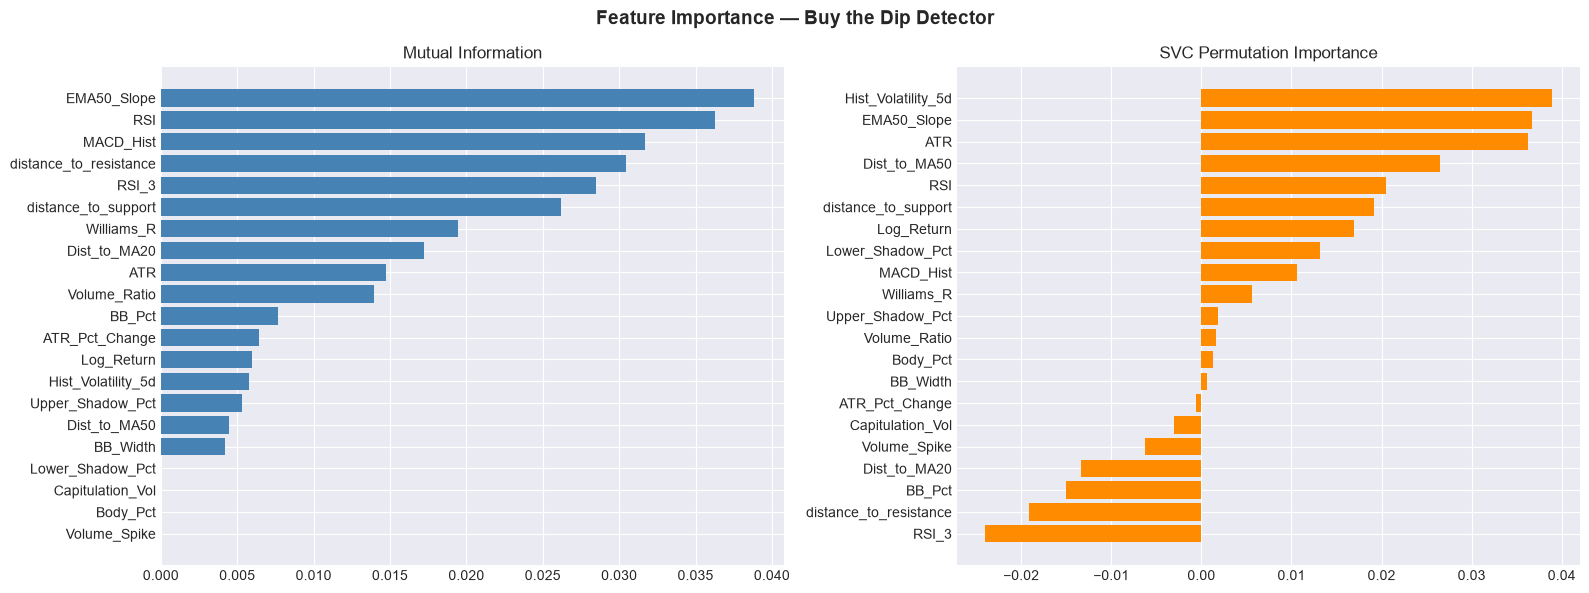


  FITUR KUAT (Top-50% di kedua metode): ['ATR', 'EMA50_Slope', 'MACD_Hist', 'RSI', 'Williams_R', 'distance_to_support']
  FITUR LEMAH (Bottom-50% di kedua metode): ['ATR_Pct_Change', 'BB_Pct', 'BB_Width', 'Body_Pct', 'Capitulation_Vol', 'Upper_Shadow_Pct', 'Volume_Spike']
    Full (21 fitur): F1=0.155
    Strong only (6 fitur): F1=0.165 ± 0.037
    => Membuang fitur lemah MENINGKATKAN performa! Gunakan daftar strong_feats.


In [4]:
# ANALISIS 3: Robustness Test (3 lapisan)
# A) Cross-period F1 tiap fold — stabil atau tidak?
# B) Permutation test — lebih baik dari random?
# C) Feature subset — strong_features lebih baik dari semua fitur?
mean_f1, std_f1 = robustness_test(df)


In [10]:
from src.visualizer import plot_interactive_candlestick
from src.label import buy_the_dip_label

# 1. Hitung ulang label dengan sweet spot Anda (15% / -5%)
# Gunakan df utuh agar tidak ada masalah data terpotong di akhir
df_label = buy_the_dip_label(df.copy(), min_return=0.15, max_drawdown=-0.05)

# 2. Potong ke In-Sample (sampai akhir 2023)
df_label = df_label.loc[:IN_SAMPLE_END]

# 3. Ubah nama kolom agar terbaca oleh visualizer.py sebagai sinyal model
df_dummy_pred = pd.DataFrame(index=df_label.index)
df_dummy_pred['classifier_signal'] = df_label['is_buy_dip'] == 1
df_dummy_pred['classifier_proba'] = 1.0  # Sekadar angka probabilitas palsu untuk hover

# 4. Plot Chart Interaktif
plot_interactive_candlestick(
    df=df_label, 
    ticker_name=TICKER, 
    classifier_predictions_df=df_dummy_pred
)


### Modelling

In [5]:
FEATURES = [
    'ATR', 'EMA50_Slope', 'MACD_Hist', 'RSI', 'Williams_R', 'distance_to_support'
    # 'Dist_to_MA20', 'EMA50_Slope', 'MACD_Hist', 'RSI', 'Williams_R', 'distance_to_resistance', 'distance_to_support'
]

In [6]:
# ==================== TRAINING: BASELINE (DummyClassifier) ====================
print("[1] Melatih Baseline (DummyClassifier - stratratified)...")

pipeline_baseline = ClassificationPipeline(target_name=TARGET_NAME, feature_cols=FEATURES)
X_bl, y_bl = pipeline_baseline.prepare_data(df_in_sample)

baseline_model = DummyClassifier(strategy='stratified', random_state=42)
pipeline_baseline.tune_and_fit(X_bl, y_bl, baseline_model, {})

all_results = []
all_results.append({'Model': 'DummyBaseline', **pipeline_baseline.metrics})

[1] Melatih Baseline (DummyClassifier - stratratified)...
   -> [HYPERPARAMETERS]: {}
   -> [LABEL DIST]: 193/2145 positif (9.0%)
   -> [TRAIN]: Precision 9.95% | Recall 9.84% | F1 9.90%
   -> [VAL F1]: 10.12%


In [7]:
# ==================== TRAINING: CHALLENGER MODELS ====================
trained_pipelines = {}

for i, model_name in enumerate(MODELS_NAME):
    config = CLASSIFIER_CONFIGS[model_name]
    print(f"\n[{i+2}] Melatih Model: {config['model_object'].__class__.__name__}...")
    
    pipeline = ClassificationPipeline(target_name=TARGET_NAME, feature_cols=FEATURES)
    X_c, y_c = pipeline.prepare_data(df_in_sample)
    pipeline.tune_and_fit(X_c, y_c, config['model_object'], config['grid_params'])
    
    all_results.append({'Model': model_name, **pipeline.metrics})
    trained_pipelines[model_name] = pipeline

# Tampilkan tabel perbandingan
df_results = pd.DataFrame(all_results)
print("\n" + "=" * 70)
print("            PERBANDINGAN SELURUH MODEL CLASSIFIER")
print("=" * 70)
df_results


[2] Melatih Model: XGBClassifier...
   -> [HYPERPARAMETERS]: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 5}
   -> [LABEL DIST]: 193/2145 positif (9.0%)
   -> [TRAIN]: Precision 66.83% | Recall 69.95% | F1 68.35%
   -> [VAL F1]: 13.06%

[3] Melatih Model: LGBMClassifier...


c:\Users\YOGA\OneDrive\Documents\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   -> [HYPERPARAMETERS]: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 5}
   -> [LABEL DIST]: 193/2145 positif (9.0%)
   -> [TRAIN]: Precision 59.59% | Recall 75.65% | F1 66.67%
   -> [VAL F1]: 12.86%

[4] Melatih Model: RandomForestClassifier...
   -> [HYPERPARAMETERS]: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}
   -> [LABEL DIST]: 193/2145 positif (9.0%)
   -> [TRAIN]: Precision 38.58% | Recall 87.56% | F1 53.57%
   -> [VAL F1]: 15.59%

[5] Melatih Model: SVC...


c:\Users\YOGA\OneDrive\Documents\Repositories\stock-forecasting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


   -> [HYPERPARAMETERS]: {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
   -> [LABEL DIST]: 193/2145 positif (9.0%)
   -> [TRAIN]: Precision 17.30% | Recall 65.80% | F1 27.40%
   -> [VAL F1]: 19.05%

            PERBANDINGAN SELURUH MODEL CLASSIFIER


,Model,Train_Precision,Train_Recall,Train_F1,Val_F1,Label_Positive_Pct
0,DummyBaseline,9.95,9.84,9.90,10.12,9.0
1,xgb_classifier,66.83,69.95,68.35,13.06,9.0
2,lgbm_classifier,59.59,75.65,66.67,12.86,9.0
3,rf_classifier,38.58,87.56,53.57,15.59,9.0
4,svc,17.30,65.80,27.40,19.05,9.0


In [8]:
# ==================== EVALUASI & PEMILIHAN MODEL TERBAIK ====================
evaluator = ClassificationEvaluator(baseline_name='DummyBaseline')
report = evaluator.generate_evaluation_report(df_results)

print("\n" + "=" * 70)
print("            LAPORAN EVALUASI MODEL CLASSIFIER")
print("=" * 70)
for key, value in report.items():
    print(f"  {key:<25}: {value}")
print("=" * 70)


            LAPORAN EVALUASI MODEL CLASSIFIER
  Target                   : is_buy_dip
  Baseline Val_F1          : 10.12%
  Challenger Model         : svc
  Challenger Val_F1        : 19.05%
  Challenger Precision     : 17.30%
  Challenger Recall        : 65.80%
  Keputusan                : Lolos (Awas Overfit)
  Model Terpilih           : svc
  Fit Status               : Overfitting
  Alasan Pemilihan         : Semua model Overfit. Memilih peringkat ke-1 sebagai fallback.


In [9]:
# ==================== SIMPAN MODEL TERPILIH ====================
clean_ticker = TICKER.split('.')[0].lower()
best_model_name = report['Model Terpilih']

if best_model_name == 'DummyBaseline':
    print("[WARNING] Model terbaik adalah Baseline. Tidak menyimpan model.")
    print("Pertimbangkan untuk menambah fitur atau mengubah threshold label.")
else:
    best_pipeline = trained_pipelines[best_model_name]
    best_pipeline.save(folder_path='../models', ticker=clean_ticker)
    print(f"\n>> Model '{best_model_name}' berhasil disimpan untuk target '{TARGET_NAME}'.")
    print(f">> Lanjutkan ke notebook 'backtest_classifier.ipynb' untuk menguji performa!")

[SAVED] Berhasil mengekspor model classifier ke: ../models/bumi/model_is_buy_dip_bumi.pkl

>> Model 'svc' berhasil disimpan untuk target 'is_buy_dip'.
>> Lanjutkan ke notebook 'backtest_classifier.ipynb' untuk menguji performa!
